In [ ]:
# %% Cell 0: Secrets & Config
# ==========================================
import os

# ── API Tokens ──
os.environ["FINMIND_TOKEN"] = "eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9"  # <-- paste your FinMind Sponsor token
os.environ["ANTHROPIC_API_KEY"] = "hGf5_2BtIWbc3_l7nDAm9dTy3qvlhnJayzjrRkiCgMdcWoqITDeOfYX9rDzyEC8OfSEZOZo6UFb"   # <-- paste if you have one (optional)

# ── Build Flags ──
FORCE_REBUILD = False    # True = rebuild 56D Feature Matrix from raw data
                        # False = use cached matrix (if exists)

print("✅ Config loaded")

✅ Config loaded


In [ ]:
# %% Cell 1: Environment Setup
# ==========================================
import os, sys, glob, shutil

print("Setting up V6.1 training environment...")

# 1. Clone / update repo
if not os.path.exists("/content/MarketMamba"):
    os.system("git clone https://github.com/FrankChen0930/MarketMamba.git /content/MarketMamba")
    print("  Repo cloned")
else:
    os.system("cd /content/MarketMamba && git pull origin main")
    print("  Repo updated")

# 2. Mount Drive FIRST — needed for cached wheels and data
from google.colab import drive
drive.mount("/content/drive")

# 3. Install dependencies
os.system("pip install -q yfinance requests pandas numpy scipy python-dotenv anthropic openai pyarrow")
os.system("pip install -q torch-geometric")

# 4. Install mamba_ssm — 3-layer strategy:
#    Layer 1 (fastest, ~10s): Drive-cached pre-built wheel
#    Layer 2 (fast):          pip binary-only (no source compile)
#    Layer 3 (slow, ~40min):  compile from source → save to Drive for next time
import torch

_cuda  = (torch.version.cuda or "?").replace(".", "")
_torch = torch.__version__.split("+")[0].replace(".", "")
_py    = f"cp{sys.version_info.major}{sys.version_info.minor}"
_key   = f"cu{_cuda}torch{_torch}{_py}"

DRIVE_WHEEL_BASE = "/content/drive/MyDrive/MarketMamba/mamba_wheels"
DRIVE_WHEEL_DIR  = f"{DRIVE_WHEEL_BASE}/{_key}"
WHEEL_BUILD_DIR  = "/tmp/mamba_wheels"
os.makedirs(WHEEL_BUILD_DIR, exist_ok=True)

print(f"  Mamba wheel key: {_key}")
print(f"  Drive wheel dir: {DRIVE_WHEEL_DIR}")

_installed = False

# --- Layer 1: Drive cache (fastest path) ---
_cached = glob.glob(f"{DRIVE_WHEEL_DIR}/*.whl") if os.path.isdir(DRIVE_WHEEL_DIR) else []
if _cached:
    print(f"  [Layer 1] Found {len(_cached)} cached wheel(s) — installing...")
    for whl in _cached:
        rc = os.system(f"pip install -q {whl}")
        print(f"    {os.path.basename(whl)} (rc={rc})")
    try:
        import importlib, importlib.util
        if importlib.util.find_spec("mamba_ssm") is not None:
            _installed = True
            print("  ✅ mamba_ssm installed from Drive cache")
        else:
            print("  ⚠️ Drive cache install failed (module not found)")
    except Exception:
        print("  ⚠️ Drive cache install failed")
else:
    # Show what keys ARE cached (helps debug version mismatches)
    _all = glob.glob(f"{DRIVE_WHEEL_BASE}/**/*.whl", recursive=True)
    if _all:
        keys = list(set(os.path.basename(os.path.dirname(w)) for w in _all))
        print(f"  [Layer 1] No wheel for key={_key}")
        print(f"    Available keys: {keys}")
    else:
        print(f"  [Layer 1] No cached wheels on Drive")

# --- Layer 2: Binary pip install (no source compile!) ---
if not _installed:
    print("  [Layer 2] Trying pip binary install (no source compile)...")
    rc = os.system("pip install -q --only-binary :all: mamba-ssm causal-conv1d 2>/dev/null")
    if rc == 0:
        try:
            import importlib.util
            if importlib.util.find_spec("mamba_ssm") is not None:
                _installed = True
                print("  ✅ mamba_ssm from pip binary")
        except: pass
    if not _installed:
        print("  No binary wheel available on PyPI for this runtime")

# --- Layer 3: Compile from source + save to Drive ---
if not _installed:
    print("  [Layer 3] Compiling from source (~40 min). Will cache to Drive.")
    rc = os.system(
        f"pip wheel mamba-ssm causal-conv1d "
        f"--no-build-isolation --no-cache-dir "
        f"-w {WHEEL_BUILD_DIR}/ "
        f"2>&1 | tail -5"
    )
    if rc == 0:
        os.system(f"pip install -q {WHEEL_BUILD_DIR}/*.whl")
        os.makedirs(DRIVE_WHEEL_DIR, exist_ok=True)
        for whl in glob.glob(f"{WHEEL_BUILD_DIR}/*.whl"):
            name = os.path.basename(whl)
            if any(p in name.lower() for p in ["mamba_ssm", "causal_conv1d"]):
                shutil.copy2(whl, f"{DRIVE_WHEEL_DIR}/{name}")
                print(f"    Cached to Drive: {name}")
        _installed = True
    else:
        print("  ⚠️ Source build failed")

# --- Verify + handle PyTorch API change ---
try:
    from mamba_ssm import Mamba
    print("  ✅ mamba_ssm import OK")
except ImportError as e:
    _err = str(e)
    if "is_opaque_value" in _err or "torch._library" in _err or "opaque_object" in _err:
        print(f"  ⚠️ PyTorch API change detected")
        print("  Installing latest mamba_ssm from GitHub (~5-10 min)...")
        # Remove incompatible cached wheel
        if os.path.isdir(DRIVE_WHEEL_DIR):
            shutil.rmtree(DRIVE_WHEEL_DIR)
            print(f"    Removed incompatible cache: {DRIVE_WHEEL_DIR}")
        rc = os.system(
            f"pip wheel git+https://github.com/state-spaces/mamba.git "
            f"git+https://github.com/Dao-AILab/causal-conv1d.git "
            f"--no-build-isolation --no-cache-dir "
            f"-w {WHEEL_BUILD_DIR}/ 2>&1 | tail -5"
        )
        if rc == 0:
            os.system(f"pip install -q {WHEEL_BUILD_DIR}/*.whl")
            # Save to Drive
            os.makedirs(DRIVE_WHEEL_DIR, exist_ok=True)
            for whl in glob.glob(f"{WHEEL_BUILD_DIR}/*.whl"):
                name = os.path.basename(whl)
                if any(p in name.lower() for p in ["mamba_ssm", "causal_conv1d"]):
                    shutil.copy2(whl, f"{DRIVE_WHEEL_DIR}/{name}")
                    print(f"    Cached GitHub wheel: {name}")
        try:
            from mamba_ssm import Mamba
            print("  ✅ mamba_ssm OK (from GitHub)")
        except ImportError as e2:
            print(f"  ❌ Still cannot import: {e2}")
    else:
        print(f"  ⚠️ mamba_ssm not available: {_err[:80]}")
        print("  Data processing cells will still work.")

# 5. Python path — V6 MUST take priority
for _k in list(sys.modules.keys()):
    if _k == "marketmamba" or _k.startswith("marketmamba."):
        del sys.modules[_k]
for _p in ["/content/MarketMamba/V6", "/content/MarketMamba"]:
    while _p in sys.path: sys.path.remove(_p)
sys.path.insert(0, "/content/MarketMamba")
sys.path.insert(0, "/content/MarketMamba/V6")

gpu  = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"
vram = torch.cuda.get_device_properties(0).total_memory / 1024**3 if torch.cuda.is_available() else 0
print(f"\n✅ Environment ready | GPU: {gpu} ({vram:.0f} GB) | Torch: {torch.__version__}")

Setting up V6.1 training environment...
  Repo cloned
Mounted at /content/drive
  Mamba wheel key: cu128torch2100cp312
  Drive wheel dir: /content/drive/MyDrive/MarketMamba/mamba_wheels/cu128torch2100cp312
  [Layer 1] Found 2 cached wheel(s) — installing...
    mamba_ssm-2.3.1-cp312-cp312-linux_x86_64.whl (rc=0)
    causal_conv1d-1.6.1-cp312-cp312-linux_x86_64.whl (rc=0)
  ✅ mamba_ssm installed from Drive cache
  ✅ mamba_ssm import OK

✅ Environment ready | GPU: NVIDIA A100-SXM4-80GB (79 GB) | Torch: 2.10.0+cu128


In [ ]:
# %% Cell 2: Restore Data from Drive
# ==========================================
import os, sys

# Re-purge (idempotent per-cell)
for _k in list(sys.modules.keys()):
    if _k == "marketmamba" or _k.startswith("marketmamba."):
        del sys.modules[_k]
for _p in ["/content/MarketMamba/V6", "/content/MarketMamba"]:
    while _p in sys.path: sys.path.remove(_p)
sys.path.insert(0, "/content/MarketMamba")
sys.path.insert(0, "/content/MarketMamba/V6")

from marketmamba.config import PROCESSED_DIR, MODELS_DIR, DATA_START_DATE, SEQ_LEN, INPUT_DIM
import pandas as pd

print(f"Config: INPUT_DIM={INPUT_DIM}, SEQ_LEN={SEQ_LEN}")

# ── Restore data snapshot from Drive ──
DRIVE_V6_DIR = "/content/drive/MyDrive/MarketMamba_V6"
DRIVE_SNAPSHOT = f"{DRIVE_V6_DIR}/processed_v6.zip"

# Force Drive directory listing (Colab lazy-mounts)
try:
    _files = os.listdir(DRIVE_V6_DIR) if os.path.isdir(DRIVE_V6_DIR) else []
    print(f"Drive contents: {_files}")
except Exception as e:
    print(f"Drive error: {e}")

if os.path.exists(DRIVE_SNAPSHOT):
    print(f"Restoring from {DRIVE_SNAPSHOT}...")
    os.makedirs(str(PROCESSED_DIR), exist_ok=True)
    rc = os.system(f"unzip -q -o {DRIVE_SNAPSHOT} -d {PROCESSED_DIR}")
    if rc == 0:
        n = len(list(PROCESSED_DIR.glob("*.parquet")))
        print(f"  ✅ Restored: {n} parquet files")
    else:
        import zipfile
        with zipfile.ZipFile(DRIVE_SNAPSHOT, 'r') as zf:
            zf.extractall(PROCESSED_DIR)
        print("  ✅ Restored via Python zipfile")
else:
    print(f"❌ Snapshot not found: {DRIVE_SNAPSHOT}")
    print("Please upload processed_v6.zip to Drive first!")

# ── Verify ──
prices_path = PROCESSED_DIR / "prices_raw.parquet"
if not prices_path.exists():
    raise FileNotFoundError("prices_raw.parquet not found! Upload data first.")

df_cal = pd.read_parquet(prices_path, columns=["Date"]).drop_duplicates()
trading_days = sorted(df_cal["Date"].astype(str).unique().tolist())
print(f"\n✅ Data verified: {len(trading_days):,} trading days ({trading_days[0]} → {trading_days[-1]})")

# List all files
print("\nAvailable parquet files:")
for f in sorted(PROCESSED_DIR.glob("*.parquet")):
    print(f"  {f.name:<45} {f.stat().st_size / 1_048_576:.1f} MB")


Config: INPUT_DIM=56, SEQ_LEN=252
Drive contents: ['checkpoints', 'processed_v6.zip', 'V6_Feature_Matrix.parquet', 'V6_Colab_Training.ipynb']
Restoring from /content/drive/MyDrive/MarketMamba_V6/processed_v6.zip...
  ✅ Restored: 23 parquet files

✅ Data verified: 5,246 trading days (2005-01-03 → 2026-05-12)

Available parquet files:
  balance_sheet_raw.parquet                     45.9 MB
  business_indicator.parquet                    0.0 MB
  cashflow_raw.parquet                          15.9 MB
  daytrade_raw.parquet                          5.2 MB
  dividend_raw.parquet                          0.9 MB
  fear_greed.parquet                            0.0 MB
  fed_rate.parquet                              0.0 MB
  financials_raw.parquet                        13.7 MB
  foreign_shareholding_raw.parquet              46.3 MB
  futures_institutional_raw.parquet             0.3 MB
  holdings_raw.parquet                          0.7 MB
  holdings_raw_BACKUP.parquet                   3.9 MB
 

In [ ]:
# %% Cell 3: Build 56D Feature Matrix + Knowledge Graph
# ==========================================
# This is the heavy computation cell (~20-30 min on Colab)
# Results auto-backup to Drive for persistence
# ==========================================
import pandas as pd
import shutil
import os

from marketmamba.data.merger import merge_all_data, validate_data_integrity
from marketmamba.data.feature_engineer import build_features, clean_and_scale
from marketmamba.knowledge.graph_builder import build_knowledge_graph
from marketmamba.config import PROCESSED_DIR, KG_CACHE_PATH

DRIVE_V6_DIR = "/content/drive/MyDrive/MarketMamba_V6"
os.makedirs(DRIVE_V6_DIR, exist_ok=True)
DRIVE_FEATURE_CACHE = f"{DRIVE_V6_DIR}/V6_Feature_Matrix.parquet"
DRIVE_KG_CACHE = f"{DRIVE_V6_DIR}/knowledge_graph_cache.npz"
DRIVE_CKPT_DIR = f"{DRIVE_V6_DIR}/checkpoints"
os.makedirs(DRIVE_CKPT_DIR, exist_ok=True)

MATRIX_CACHE = PROCESSED_DIR / "V6_Feature_Matrix.parquet"

# ── Restore from Drive if available ──
if not MATRIX_CACHE.exists() and os.path.exists(DRIVE_FEATURE_CACHE):
    print("Restoring feature matrix from Drive...")
    shutil.copy(DRIVE_FEATURE_CACHE, str(MATRIX_CACHE))
    print(f"  Restored ({os.path.getsize(DRIVE_FEATURE_CACHE) / 1e9:.2f} GB)")

# ── Build or Load ──
if MATRIX_CACHE.exists() and not FORCE_REBUILD:
    print("Loading cached feature matrix...")
    df = pd.read_parquet(MATRIX_CACHE)
else:
    print("Building V6.1 56D feature matrix...")
    print("  This takes ~20-30 min on Colab. Be patient.")
    data = merge_all_data()
    integrity = validate_data_integrity(data)
    print(f"  Stocks: {integrity.get('n_stocks')} | Dates: {integrity.get('n_dates')}")
    print(f"  Range: {integrity.get('date_range')}")

    df = build_features(
        df_price         = data["prices"],
        df_inst          = data["inst"],
        df_margin        = data["margin"],
        df_per           = data["per"],
        df_securities    = data["securities"],
        df_market_value  = data["market_value"],
        df_daytrade      = data["daytrade"],
        df_holdings      = data["holdings"],
        df_rev           = data["revenue"],
        df_fin           = data["financials"],
        df_balance_sheet = data["balance_sheet"],
        df_cashflow      = data["cashflow"],
        df_macro         = data["macro"],
        # V6.1 new data sources
        df_futures_inst  = data.get("futures_inst"),
        df_options_inst  = data.get("options_inst"),
        df_dividend      = data.get("dividend"),
        df_foreign_shareholding = data.get("foreign_shareholding"),
        df_fear_greed    = data.get("fear_greed"),
        df_business_indicator = data.get("business_indicator"),
        df_fed_rate      = data.get("fed_rate"),
    )
    df = clean_and_scale(df)
    df.to_parquet(MATRIX_CACHE)
    print(f"  ✅ Feature matrix saved: {df.shape}")

    # Auto-backup to Drive
    shutil.copy(str(MATRIX_CACHE), DRIVE_FEATURE_CACHE)
    print(f"  ✅ Backed up to Drive ({os.path.getsize(DRIVE_FEATURE_CACHE) / 1e9:.2f} GB)")

n_features = df.shape[1] - 5  # minus Date, stock_id, Alpha_5d/20d/60d
print(f"\n✅ Feature matrix: {df.shape[0]:,} rows × {df.shape[1]} cols ({n_features} features)")
print(f"   Date range: {df['Date'].min()} → {df['Date'].max()}")
print(f"   Stocks: {df['stock_id'].nunique():,}")

Restoring feature matrix from Drive...
  Restored (2.25 GB)
Loading cached feature matrix...

✅ Feature matrix: 9,466,889 rows × 61 cols (56 features)
   Date range: 2005-01-03 00:00:00 → 2026-05-12 00:00:00
   Stocks: 44,222


In [ ]:
# %% Cell 3b: Knowledge Graph (lightweight — no merge_all_data)
# ==========================================
# Only reads prices_raw.parquet + stock_info.parquet
# Much faster than Cell 3 — should complete in 1-2 minutes
# ==========================================
import pandas as pd
import shutil, os
from marketmamba.knowledge.graph_builder import build_knowledge_graph
from marketmamba.config import PROCESSED_DIR, KG_CACHE_PATH

DRIVE_V6_DIR = "/content/drive/MyDrive/MarketMamba_V6"
DRIVE_KG_CACHE = f"{DRIVE_V6_DIR}/knowledge_graph_cache.npz"

KG_REBUILD = False

# Restore from Drive if available
if not KG_CACHE_PATH.exists() and os.path.exists(DRIVE_KG_CACHE):
    print("Restoring KG from Drive...")
    os.makedirs(str(KG_CACHE_PATH.parent), exist_ok=True)
    shutil.copy(DRIVE_KG_CACHE, str(KG_CACHE_PATH))
    print("  ✅ KG restored from Drive")

if not KG_CACHE_PATH.exists() or KG_REBUILD:
    print("Building Knowledge Graph (lightweight)...")

    # Load ONLY prices — no need for merge_all_data() (saves 580MB + 5 min)
    df_prices = pd.read_parquet(PROCESSED_DIR / "prices_raw.parquet")
    df_universe = df_prices[["stock_id"]].drop_duplicates()
    print(f"  Universe: {len(df_universe)} stocks")

    # Load sector info from local parquet (fetched locally, much more reliable)
    stock_info_path = PROCESSED_DIR / "stock_info.parquet"
    if stock_info_path.exists():
        df_info = pd.read_parquet(stock_info_path)
        df_universe = df_universe.merge(
            df_info[["stock_id", "industry_category"]], on="stock_id", how="left"
        )
        df_universe["industry_category"] = df_universe["industry_category"].fillna("Unknown")
        n_sectors = df_universe["industry_category"].nunique()
        print(f"  Sector info loaded: {n_sectors} industries")
    else:
        # Fallback: try FinMind API (may fail on Colab)
        try:
            from marketmamba.data.fetcher import _fetch_universe_from_finmind
            df_univ = _fetch_universe_from_finmind()
            df_universe = df_universe.merge(
                df_univ[["stock_id", "industry_category"]], on="stock_id", how="left"
            )
            print("  Sector info from FinMind API")
        except Exception as e:
            print(f"  Could not fetch sector info: {e}")
            df_universe["industry_category"] = "Unknown"

    build_knowledge_graph(df_universe, df_prices, force_rebuild=KG_REBUILD)

    # Backup to Drive
    if KG_CACHE_PATH.exists():
        shutil.copy(str(KG_CACHE_PATH), DRIVE_KG_CACHE)
        print(f"  ✅ KG built & backed up to Drive")

    # Free memory
    del df_prices, df_universe
    import gc; gc.collect()
else:
    print(f"✅ KG loaded from cache")

✅ KG loaded from cache


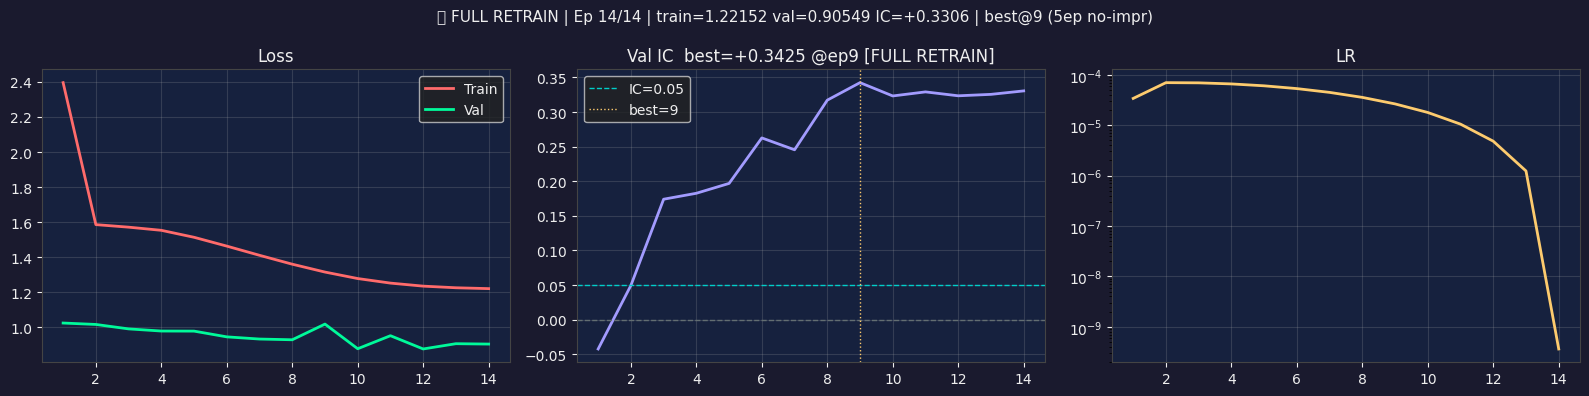


✅ Training complete!
   Mode:       FULL RETRAIN (Production)
   Best Epoch: 12 / 14
   Val Loss:   0.87760
   Best IC:    +0.3425
   Checkpoint: /content/drive/MyDrive/MarketMamba_V6/checkpoints/v6_final.pt (already on Drive)

   🔥 This is your PRODUCTION model — trained on ALL data for 14 epochs.
   🔥 Deploy this v6_final.pt for daily inference.


In [ ]:
%run /content/MarketMamba/V6/notebooks/V6_FullRetrain_Cell.py

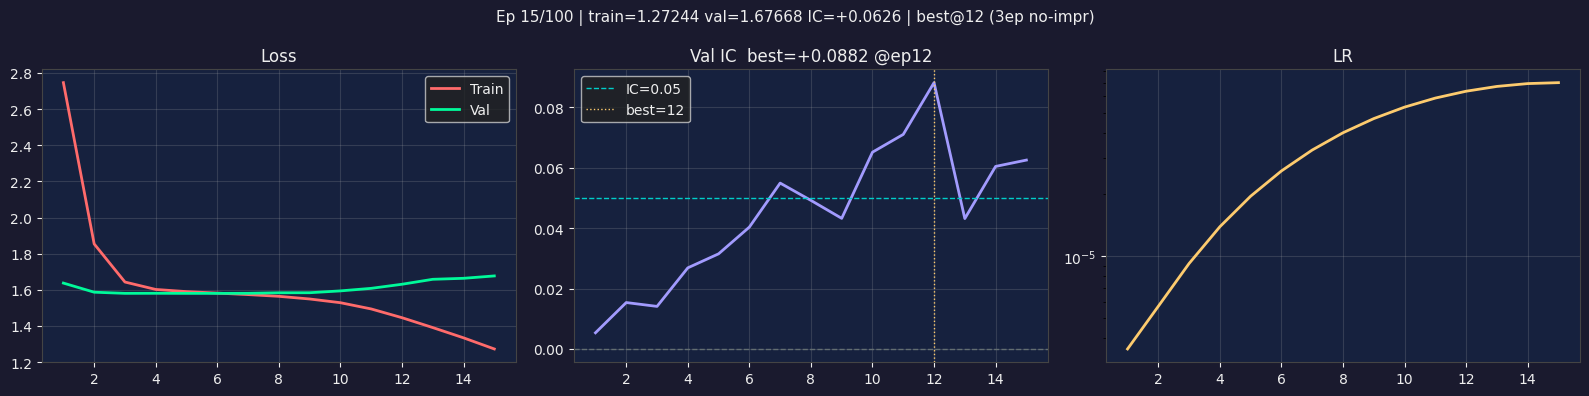

  Ep 016 [200/4429] loss=1.24859 | 194s | ETA 4099s
  Ep 016 [400/4429] loss=1.24526 | 388s | ETA 3907s
  Ep 016 [600/4429] loss=1.23683 | 578s | ETA 3686s
  Ep 016 [800/4429] loss=1.23550 | 775s | ETA 3518s
  Ep 016 [1000/4429] loss=1.23616 | 967s | ETA 3315s
  Ep 016 [1200/4429] loss=1.23215 | 1164s | ETA 3132s
  Ep 016 [1400/4429] loss=1.23253 | 1360s | ETA 2943s
  Ep 016 [1600/4429] loss=1.23220 | 1547s | ETA 2735s
  Ep 016 [1800/4429] loss=1.23104 | 1740s | ETA 2541s
  Ep 016 [2000/4429] loss=1.22943 | 1933s | ETA 2348s
  Ep 016 [2200/4429] loss=1.22741 | 2121s | ETA 2149s
  Ep 016 [2400/4429] loss=1.22616 | 2310s | ETA 1953s
  Ep 016 [2600/4429] loss=1.22511 | 2501s | ETA 1759s
  Ep 016 [2800/4429] loss=1.22416 | 2694s | ETA 1568s
  Ep 016 [3000/4429] loss=1.22291 | 2885s | ETA 1374s
  Ep 016 [3200/4429] loss=1.22106 | 3074s | ETA 1180s


In [ ]:
# %% Cell 4: Train V6.1 Model
# ==========================================
# Full training with IC-based early stopping
# ==========================================
import torch
from marketmamba.models.trainer import train_model
from marketmamba.config import MODELS_DIR

all_dates = sorted(df["Date"].astype(str).unique().tolist())
cutoff_train_end = "2023-12-31"

train_dates = [d for d in all_dates if d <= cutoff_train_end]
val_dates   = [d for d in all_dates if d > cutoff_train_end]

FINAL_EPOCHS   = 100
N_SAMPLE_TRAIN = None   # All stocks. If OOM → set 2000
EARLY_STOP_IC  = 15

from marketmamba import config as _cfg
_cfg.N_SAMPLE_TRAIN = N_SAMPLE_TRAIN

print(f"Training Setup:")
print(f"  Train: {len(train_dates)} days ({train_dates[0]} → {train_dates[-1]})")
print(f"  Val:   {len(val_dates)} days ({val_dates[0]} → {val_dates[-1]})")
print(f"  Epochs: {FINAL_EPOCHS} (IC early stop patience={EARLY_STOP_IC})")
print(f"  N_SAMPLE: {N_SAMPLE_TRAIN or 'ALL'}")
print(f"  GPU: {torch.cuda.get_device_name(0)}")

# ── Live plot callback ──
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import clear_output, display

def live_plot(history, epoch, epochs):
    clear_output(wait=True)
    ep = list(range(1, len(history.train_loss) + 1))

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    fig.patch.set_facecolor("#1a1a2e")
    for ax in axes:
        ax.set_facecolor("#16213e")
        ax.tick_params(colors="#eee")
        ax.title.set_color("#eee")
        for spine in ax.spines.values(): spine.set_edgecolor("#444")

    axes[0].plot(ep, history.train_loss, color="#ff6b6b", lw=2, label="Train")
    axes[0].plot(ep, history.val_loss,   color="#00fa9a", lw=2, label="Val")
    axes[0].set_title("Loss"); axes[0].legend(facecolor="#222", labelcolor="#eee"); axes[0].grid(alpha=0.2)

    axes[1].plot(ep, history.val_ic, color="#a29bfe", lw=2)
    axes[1].axhline(0, color="#636e72", ls="--", lw=1)
    axes[1].axhline(0.05, color="#00cec9", ls="--", lw=1, label="IC=0.05")
    best_ic = max(history.val_ic)
    best_ep = history.best_ic_epoch
    axes[1].axvline(best_ep, color="#fdcb6e", ls=":", lw=1, label=f"best={best_ep}")
    axes[1].set_title(f"Val IC  best={best_ic:+.4f} @ep{best_ep}")
    axes[1].legend(facecolor="#222", labelcolor="#eee"); axes[1].grid(alpha=0.2)

    axes[2].plot(ep, history.lr, color="#fdcb6e", lw=2)
    axes[2].set_title("LR"); axes[2].set_yscale("log"); axes[2].grid(alpha=0.2)

    no_impr = epoch - best_ep
    fig.suptitle(f"Ep {epoch}/{epochs} | train={history.train_loss[-1]:.5f} val={history.val_loss[-1]:.5f} IC={history.val_ic[-1]:+.4f} | best@{best_ep} ({no_impr}ep no-impr)", color="#eee", fontsize=11)
    plt.tight_layout(); display(fig); plt.close(fig)

# ── Train ──
print("\n🚀 Starting training...")
print(f"   ⚡ Checkpoints auto-backup to Drive on every IC improvement")
model, history = train_model(
    df              = df,
    train_dates     = train_dates,
    val_dates       = val_dates,
    epochs          = FINAL_EPOCHS,
    early_stop      = EARLY_STOP_IC,
    checkpoint_name = "v6_final.pt",
    on_epoch_end    = live_plot,
    ic_mode         = True,
    checkpoint_backup_dir = DRIVE_CKPT_DIR,   # ← immediate Drive backup!
)

# ── Save summary ──
live_plot(history, len(history.train_loss), FINAL_EPOCHS)
print(f"\n✅ Training complete!")
print(f"   Best Epoch: {history.best_epoch} / {len(history.train_loss)}")
print(f"   Val Loss:   {history.best_val_loss:.5f}")
print(f"   Best IC:    {max(history.val_ic):+.4f}")
print(f"   Checkpoint: {DRIVE_CKPT_DIR}/v6_final.pt (already on Drive)")

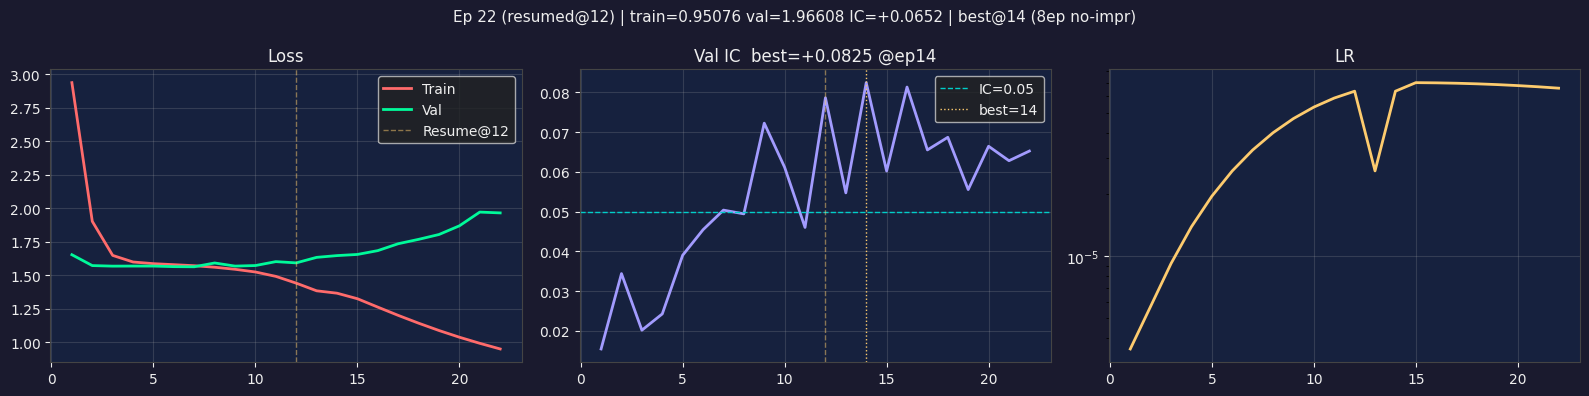

  Ep 023 [200/4429] loss=0.92429 | 187s | ETA 3960s
  Ep 023 [400/4429] loss=0.92078 | 374s | ETA 3772s
  Ep 023 [600/4429] loss=0.92493 | 563s | ETA 3595s
  Ep 023 [800/4429] loss=0.91893 | 754s | ETA 3420s
  Ep 023 [1000/4429] loss=0.92088 | 951s | ETA 3260s


KeyboardInterrupt: 

In [ ]:
# %% Cell 4b: Resume Training (run this instead of Cell 4 after reconnect)
# ==========================================
# Loads checkpoint from Drive and continues training.
# Skip Cell 4 entirely — run Cell 2 → Cell 3 → Cell 3b → Cell 4b
# ==========================================
import torch, shutil, os
import pandas as pd
from marketmamba.models.trainer import train_model, TrainingHistory
from marketmamba.models.architecture import MarketMambaV6
from marketmamba.config import MODELS_DIR, SEQ_LEN, INPUT_DIM, FEATURE_COLS
from marketmamba.config import KG_CACHE_PATH, AMP_ENABLED, GRAD_CLIP_NORM
from marketmamba.config import LR, WARMUP_PCT, LOSS_WEIGHTS, PRED_HORIZONS, N_SAMPLE_TRAIN
from marketmamba.models.trainer import (
    TemporalCrossSectionDataset, make_dataloader,
    build_kg_csr, multi_horizon_loss, compute_ic,
)

DRIVE_V6_DIR = "/content/drive/MyDrive/MarketMamba_V6"
DRIVE_CKPT_DIR = f"{DRIVE_V6_DIR}/checkpoints"

# ── Restore checkpoint ──
ckpt_drive = f"{DRIVE_CKPT_DIR}/v6_final.pt"
ckpt_local = MODELS_DIR / "v6_final.pt"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

if os.path.exists(ckpt_drive):
    shutil.copy(ckpt_drive, str(ckpt_local))
    print(f"✅ Checkpoint restored from Drive")
elif ckpt_local.exists():
    print(f"✅ Using local checkpoint")
else:
    raise FileNotFoundError("No checkpoint found! Run Cell 4 first.")

torch.serialization.add_safe_globals([TrainingHistory])
ckpt = torch.load(ckpt_local, map_location="cuda", weights_only=False)
start_epoch = ckpt["epoch"]
best_ic = ckpt.get("val_ic", 0)
prev_history = ckpt.get("history")
print(f"  Resuming from epoch {start_epoch} | best IC={best_ic:+.4f}")
if prev_history:
    print(f"  Previous history: {len(prev_history.train_loss)} epochs")

# ── Setup ──
RESUME_EPOCHS = 50   # Additional epochs to train
EARLY_STOP_IC = 15
RESUME_LR = 5e-5     # Lower LR for fine-tuning phase

from marketmamba import config as _cfg
_cfg.N_SAMPLE_TRAIN = None   # All stocks

all_dates = sorted(df["Date"].astype(str).unique().tolist())
cutoff_train_end = "2023-12-31"
train_dates = [d for d in all_dates if d <= cutoff_train_end]
val_dates   = [d for d in all_dates if d > cutoff_train_end]

train_ds = TemporalCrossSectionDataset(df, train_dates, mode="train", n_sample=None)
val_ds   = TemporalCrossSectionDataset(df, val_dates,   mode="val",   n_sample=None)
train_loader = make_dataloader(train_ds, shuffle=True)
val_loader   = make_dataloader(val_ds,   shuffle=False)

# Model
device = torch.device("cuda")
model = MarketMambaV6().to(device)
model.load_state_dict(ckpt["state_dict"])
print(f"  Model loaded ({model.n_parameters:,} params)")

# Optimizer + Scheduler
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR
from torch.amp import GradScaler, autocast
import torch.nn as nn
import numpy as np, time

optimizer = AdamW(model.parameters(), lr=RESUME_LR, weight_decay=1e-4)
total_steps = RESUME_EPOCHS * max(len(train_loader), 1)
scheduler = OneCycleLR(optimizer, max_lr=RESUME_LR, total_steps=total_steps,
                       pct_start=0.05, anneal_strategy="cos")
scaler = GradScaler('cuda', enabled=AMP_ENABLED)

# Restore optimizer state if available
if "optimizer" in ckpt:
    try:
        optimizer.load_state_dict(ckpt["optimizer"])
        print("  Optimizer state restored")
    except:
        print("  Optimizer state mismatch — using fresh optimizer")
if "scheduler" in ckpt and "scaler" in ckpt:
    try:
        # Don't restore scheduler — we're using a new OneCycleLR for resume
        scaler.load_state_dict(ckpt["scaler"])
        print("  Scaler state restored")
    except:
        pass

# KG
kg_csr, stock_to_idx = build_kg_csr()

# ── Live plot ──
import matplotlib; matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import clear_output, display

# Merge previous history
history = TrainingHistory()
if prev_history:
    history.train_loss = list(prev_history.train_loss)
    history.val_loss   = list(prev_history.val_loss)
    history.val_ic     = list(prev_history.val_ic)
    history.lr         = list(prev_history.lr)
    history.breakdown  = list(prev_history.breakdown)

def live_plot_resume(h, epoch, total):
    clear_output(wait=True)
    ep = list(range(1, len(h.train_loss) + 1))
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    fig.patch.set_facecolor("#1a1a2e")
    for ax in axes:
        ax.set_facecolor("#16213e"); ax.tick_params(colors="#eee")
        ax.title.set_color("#eee")
        for s in ax.spines.values(): s.set_edgecolor("#444")

    # Mark resume point
    resume_ep = start_epoch

    axes[0].plot(ep, h.train_loss, color="#ff6b6b", lw=2, label="Train")
    axes[0].plot(ep, h.val_loss,   color="#00fa9a", lw=2, label="Val")
    axes[0].axvline(resume_ep, color="#fdcb6e", ls="--", lw=1, alpha=0.5, label=f"Resume@{resume_ep}")
    axes[0].set_title("Loss"); axes[0].legend(facecolor="#222", labelcolor="#eee"); axes[0].grid(alpha=0.2)

    axes[1].plot(ep, h.val_ic, color="#a29bfe", lw=2)
    axes[1].axhline(0.05, color="#00cec9", ls="--", lw=1, label="IC=0.05")
    best_ic_val = max(h.val_ic)
    best_ep = h.best_ic_epoch
    axes[1].axvline(best_ep, color="#fdcb6e", ls=":", lw=1, label=f"best={best_ep}")
    axes[1].axvline(resume_ep, color="#fdcb6e", ls="--", lw=1, alpha=0.5)
    axes[1].set_title(f"Val IC  best={best_ic_val:+.4f} @ep{best_ep}")
    axes[1].legend(facecolor="#222", labelcolor="#eee"); axes[1].grid(alpha=0.2)

    axes[2].plot(ep, h.lr, color="#fdcb6e", lw=2)
    axes[2].set_title("LR"); axes[2].set_yscale("log"); axes[2].grid(alpha=0.2)

    total_ep = len(h.train_loss)
    no_impr = total_ep - best_ep
    fig.suptitle(f"Ep {total_ep} (resumed@{resume_ep}) | train={h.train_loss[-1]:.5f} val={h.val_loss[-1]:.5f} IC={h.val_ic[-1]:+.4f} | best@{best_ep} ({no_impr}ep no-impr)", color="#eee", fontsize=11)
    plt.tight_layout(); display(fig); plt.close(fig)

# ── Resume Training Loop ──
print(f"\n🚀 Resuming training from epoch {start_epoch + 1}...")
print(f"   Additional epochs: {RESUME_EPOCHS} | LR: {RESUME_LR}")

best_val = best_ic
no_impr = 0
from marketmamba.models.trainer import get_batch_edges_csr

for epoch in range(start_epoch + 1, start_epoch + RESUME_EPOCHS + 1):
    t0 = time.time()

    model.train()
    train_losses = []
    for batch_idx, (X, Y, batch_stocks) in enumerate(train_loader):
        if X.shape[0] <= 1: continue
        X, Y = X.to(device), Y.to(device)
        edge_index, edge_attr = get_batch_edges_csr(batch_stocks, kg_csr, stock_to_idx, device)
        optimizer.zero_grad()
        with autocast('cuda', enabled=AMP_ENABLED):
            preds = model(X, edge_index, edge_attr)
            loss, brkdn = multi_horizon_loss(preds, Y)
        if not loss.requires_grad: continue
        if torch.isnan(loss) or torch.isinf(loss): continue
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        train_losses.append(brkdn["loss_total"])

        if (batch_idx + 1) % 200 == 0:
            elapsed = time.time() - t0
            total_b = len(train_loader)
            eta = elapsed / (batch_idx + 1) * (total_b - batch_idx - 1)
            print(f"  Ep {epoch:03d} [{batch_idx+1}/{total_b}] loss={float(np.mean(train_losses)):.5f} | {elapsed:.0f}s | ETA {eta:.0f}s", flush=True)

    if not train_losses: continue
    avg_train = float(np.mean(train_losses))

    model.eval()
    val_losses, val_ics = [], []
    with torch.no_grad():
        for X, Y, batch_stocks in val_loader:
            if X.shape[0] <= 1: continue
            X, Y = X.to(device), Y.to(device)
            edge_index, edge_attr = get_batch_edges_csr(batch_stocks, kg_csr, stock_to_idx, device)
            with autocast('cuda', enabled=AMP_ENABLED):
                preds = model(X, edge_index, edge_attr)
                loss, _ = multi_horizon_loss(preds, Y)
            val_losses.append(loss.item())
            ic = compute_ic(preds[:, 1].cpu().numpy(), Y[:, 1].cpu().numpy())
            val_ics.append(ic)

    avg_val = float(np.mean(val_losses)) if val_losses else float("inf")
    avg_ic  = float(np.mean(val_ics)) if val_ics else 0.0
    cur_lr  = scheduler.get_last_lr()[0]

    history.train_loss.append(avg_train)
    history.val_loss.append(avg_val)
    history.val_ic.append(avg_ic)
    history.lr.append(cur_lr)
    history.breakdown.append({})

    print(f"Epoch {epoch:03d} | train={avg_train:.5f} val={avg_val:.5f} IC={avg_ic:+.4f} lr={cur_lr:.2e} | {time.time()-t0:.0f}s", flush=True)
    live_plot_resume(history, epoch, start_epoch + RESUME_EPOCHS)

    if avg_ic > best_val:
        best_val = avg_ic
        no_impr = 0
        torch.save(
            {"epoch": epoch, "state_dict": model.state_dict(),
             "optimizer": optimizer.state_dict(),
             "scheduler": scheduler.state_dict(),
             "scaler": scaler.state_dict(),
             "best_val": best_val, "no_impr": no_impr,
             "val_loss": avg_val, "val_ic": avg_ic, "history": history},
            ckpt_local,
        )
        shutil.copy(str(ckpt_local), f"{DRIVE_CKPT_DIR}/v6_final.pt")
        print(f"  ✅ Checkpoint saved & backed up (IC={avg_ic:+.4f})", flush=True)
    else:
        no_impr += 1
        if no_impr >= EARLY_STOP_IC:
            print(f"  🛑 Early stop at epoch {epoch} (IC no-improve {EARLY_STOP_IC} ep)", flush=True)
            break

# Final reload best
if ckpt_local.exists():
    ckpt_final = torch.load(ckpt_local, map_location=device, weights_only=False)
    model.load_state_dict(ckpt_final["state_dict"])
    print(f"\n✅ Resume training complete!")
    print(f"   Best epoch: {ckpt_final['epoch']} | IC: {ckpt_final['val_ic']:+.4f}")
live_plot_resume(history, len(history.train_loss), start_epoch + RESUME_EPOCHS)

In [ ]:
# %% Cell 5: Walk-Forward Validation (Optional)
# ==========================================
# Full 36-fold Walk-Forward — takes 4-8 hours
# Only run after Cell 4 confirms training works
# ==========================================
RUN_FULL_WF = False
RESUME_FROM_FOLD = 1

if RUN_FULL_WF:
    import json, shutil
    from marketmamba.evaluation.walk_forward import run_walk_forward

    DRIVE_WF_DIR = f"{DRIVE_V6_DIR}/wf_results"
    os.makedirs(DRIVE_WF_DIR, exist_ok=True)

    def train_fold(df, train_dates, val_dates):
        m, h = train_model(df, train_dates, val_dates, epochs=40, checkpoint_name="v6_wf_fold.pt")
        fold_ckpt = MODELS_DIR / "v6_wf_fold.pt"
        if fold_ckpt.exists():
            shutil.copy(str(fold_ckpt), f"{DRIVE_CKPT_DIR}/v6_wf_fold.pt")
        return m

    wf_summary = run_walk_forward(
        df=df,
        train_fn=train_fold,
        train_start="2005-01-01",
        save_results=True,
        resume_from_fold=RESUME_FROM_FOLD,
    )
    wf_summary.print_report()

    wf_path = MODELS_DIR / "walk_forward_results.parquet"
    if wf_path.exists():
        shutil.copy(str(wf_path), f"{DRIVE_WF_DIR}/walk_forward_results.parquet")
        print("✅ Walk-Forward results backed up to Drive")
else:
    print("Walk-Forward skipped (RUN_FULL_WF=False)")
    print("Set RUN_FULL_WF=True when ready for the full 4-8 hour run")


In [ ]:
# %% Cell 6: Download Model
# ==========================================
import shutil
from marketmamba.config import MODELS_DIR

final_ckpt = MODELS_DIR / "v6_final.pt"
best_ckpt  = MODELS_DIR / "v6_best.pt"

if final_ckpt.exists():
    shutil.copy(final_ckpt, best_ckpt)
    print(f"✅ Checkpoint: {best_ckpt}")
    print(f"   Size: {best_ckpt.stat().st_size / 1e6:.1f} MB")

    # Copy to Drive for easy access
    shutil.copy(str(best_ckpt), f"{DRIVE_CKPT_DIR}/v6_best.pt")
    print(f"   ✅ Also saved to Drive: {DRIVE_CKPT_DIR}/v6_best.pt")
else:
    print("❌ v6_final.pt not found. Run Cell 4 first.")